# Negotiation telemetry metrics

Primary outcomes (by arm): **accepted below Nash**, **accepted with negative profit**, **sent below Nash**, **sent with negative profit**, plus two-sample z-tests. Metric family 3 covers agentic draft selection.

1. Run sessions, then `pixi run python analysis/export_tables.py`
2. Open this notebook from the project root (pixi shell includes pandas, scipy)

In [102]:
from pathlib import Path

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if Path.cwd().name == 'analysis':
    os.chdir('..')

DATA = Path('analysis/data')
FIGURES = Path('analysis/figures')
FIGURES.mkdir(parents=True, exist_ok=True)


ev = pd.read_csv(DATA / 'offer_events.csv')
drafts = pd.read_csv(DATA / 'draft_offers.csv')
llm = pd.read_csv(DATA / 'llm_calls.csv')

print('offer_events', ev.shape)
print('draft_offers', drafts.shape)
print('llm_calls', llm.shape)
mask = ev["room"] == 108
ev[mask].head()

offer_events (183, 36)
draft_offers (156, 32)
llm_calls (183, 27)


,id,turn,stamp,sender,origin,price,quantity,is_valid,is_complete,profit_bot,...,room,arm,human_role,bot_role,market_price,production_cost,class_name,agentic_evaluation_help,num_rounds,player_id
93,94,1,1.787596e+09,human,interface,4.50,94,1,1,-57.8100,...,108,hybrid,Retailer,Supplier,12,3,Class B,0,60,181
94,95,2,1.787596e+09,bot,chat_parsed,9.05,94,1,1,168.8710,...,108,hybrid,Retailer,Supplier,12,3,Class B,0,60,181
95,96,2,1.787596e+09,human,interface,5.20,93,1,1,-20.2740,...,108,hybrid,Retailer,Supplier,12,3,Class B,0,60,181
96,97,3,1.787596e+09,bot,chat_parsed,9.00,93,1,1,168.7950,...,108,hybrid,Retailer,Supplier,12,3,Class B,0,60,181
97,98,3,1.787596e+09,human,interface,6.10,91,1,1,29.5295,...,108,hybrid,Retailer,Supplier,12,3,Class B,0,60,181


## Primary metrics — proportions by arm

| Metric | Population |
|--------|------------|
| accepted below Nash | accepted human offers (`surplus_bot < 0`) |
| accepted with negative profit | accepted human offers (`profit_bot < 0`) |
| sent below Nash | bot-sent offers (`surplus_bot < 0`) |
| sent with negative profit | bot-sent offers (`profit_bot < 0`) |

In [103]:
R = ev.query("sender == 'human' and is_complete == True and is_valid == True").copy()
A = R.query("accepted == True").copy()
S = ev.query("sender == 'bot' and is_mirror == False and is_complete == True and is_valid == True").copy()

A = A.assign(
    below_nash=A['surplus_bot'] < 0,
    neg_profit=A['profit_bot'] < 0,
)
S = S.assign(
    below_nash=S['surplus_bot'] < 0,
    neg_profit=S['profit_bot'] < 0,
)

metrics = pd.concat([
    A.groupby('arm').agg(
        accepted_below_nash=('below_nash', 'mean'),
        accepted_neg_profit=('neg_profit', 'mean'),
        n_accepted=('below_nash', 'size'),
    ),
    S.groupby('arm').agg(
        sent_below_nash=('below_nash', 'mean'),
        sent_neg_profit=('neg_profit', 'mean'),
        n_sent=('below_nash', 'size'),
    ),
], axis=1).round(3)
metrics

,accepted_below_nash,accepted_neg_profit,n_accepted,sent_below_nash,sent_neg_profit,n_sent
arm,,,,,,
agentic,0.0,0.0,6,0.0,0.0,45
hybrid,0.0,0.0,6,0.0,0.0,42


## Inferential statistics — agentic vs hybrid

Two-sample **z-tests** for each of the four proportion metrics above.

In [104]:
from scipy import stats

ARM_A, ARM_B = 'agentic', 'hybrid'


def _proportions_ztest(count, nobs) -> tuple[float, float]:
    count = np.asarray(count, dtype=float)
    nobs = np.asarray(nobs, dtype=float)
    p1, p2 = count / nobs
    p_pool = count.sum() / nobs.sum()
    se = np.sqrt(p_pool * (1 - p_pool) * (1 / nobs[0] + 1 / nobs[1]))
    if se == 0:
        return 0.0, 1.0
    z = (p1 - p2) / se
    p = 2 * stats.norm.sf(abs(z))
    return float(z), float(p)


def prop_ztest(df: pd.DataFrame, mask_col: str) -> dict:
    a = df.loc[df['arm'] == ARM_A]
    b = df.loc[df['arm'] == ARM_B]
    if a.empty or b.empty:
        return {'z': np.nan, 'p': np.nan, 'note': 'missing arm'}
    count = [a[mask_col].sum(), b[mask_col].sum()]
    nobs = [len(a), len(b)]
    z, p = _proportions_ztest(count, nobs)
    return {
        'p_agentic': a[mask_col].mean(),
        'p_hybrid': b[mask_col].mean(),
        'n_agentic': nobs[0],
        'n_hybrid': nobs[1],
        'z': z,
        'p': p,
    }


prop_tests = pd.DataFrame({
    'accepted_below_nash': prop_ztest(A, 'below_nash'),
    'accepted_neg_profit': prop_ztest(A, 'neg_profit'),
    'sent_below_nash': prop_ztest(S, 'below_nash'),
    'sent_neg_profit': prop_ztest(S, 'neg_profit'),
}).T
prop_tests

,p_agentic,p_hybrid,n_agentic,n_hybrid,z,p
accepted_below_nash,0.0,0.0,6.0,6.0,0.0,1.0
accepted_neg_profit,0.0,0.0,6.0,6.0,0.0,1.0
sent_below_nash,0.0,0.0,45.0,42.0,0.0,1.0
sent_neg_profit,0.0,0.0,45.0,42.0,0.0,1.0


## Metric family 3 — agentic draft generation and selection

### Chosen-draft fallback (when `draft_offers.chosen` is empty)

Joins each `send_offer` in `llm_calls` to the preceding `propose_offer` on the same turn, then picks the matching draft slot. Used for plots and selection stats when telemetry `mark_chosen` did not run (old sessions).

In [105]:
import ast
import json


def _parse_tool_args(raw):
    if pd.isna(raw) or raw == '':
        return {}
    if isinstance(raw, dict):
        return raw
    try:
        return json.loads(raw)
    except (json.JSONDecodeError, TypeError):
        return ast.literal_eval(raw)


def infer_chosen_drafts(draft_df: pd.DataFrame, llm_df: pd.DataFrame) -> pd.DataFrame:
    """Infer sent draft rows from send_offer -> propose_offer -> slot."""
    agentic_llm = llm_df.query("arm == 'agentic'").copy()
    proposes = agentic_llm.loc[agentic_llm.tool_name == 'propose_offer', [
        'session_code', 'participant_code', 'round_number', 'turn', 'step',
    ]].rename(columns={'step': 'propose_step'})
    sends = agentic_llm.loc[agentic_llm.tool_name == 'send_offer'].copy()

    rows = []
    for _, send in sends.iterrows():
        args = _parse_tool_args(send['tool_arguments'])
        offer_number = args.get('offer_number')
        if offer_number is None:
            continue
        prior = proposes[
            (proposes['session_code'] == send['session_code'])
            & (proposes['participant_code'] == send['participant_code'])
            & (proposes['round_number'] == send['round_number'])
            & (proposes['turn'] == send['turn'])
            & (proposes['propose_step'] < send['step'])
        ]
        if prior.empty:
            continue
        propose_step = prior['propose_step'].max()
        match = draft_df[
            (draft_df['participant_code'] == send['participant_code'])
            & (draft_df['round_number'] == send['round_number'])
            & (draft_df['turn'] == send['turn'])
            & (draft_df['step'] == propose_step)
            & (draft_df['slot'] == int(offer_number))
        ]
        if len(match) == 1:
            rows.append(match.iloc[0])
    return pd.DataFrame(rows)


agentic_drafts = drafts.query("arm == 'agentic'").copy()

if agentic_drafts['chosen'].any():
    chosen_effective = agentic_drafts.query('chosen == True').copy()
    chosen_source = 'telemetry'
else:
    chosen_effective = infer_chosen_drafts(agentic_drafts, llm)
    chosen_source = 'llm_calls fallback'

print(f'Chosen drafts: {len(chosen_effective)} ({chosen_source})')
chosen_effective.head()

Chosen drafts: 45 (llm_calls fallback)


,id,turn,step,call_id,slot,price,quantity,profit_bot,profit_user,nash_profit,...,room,arm,human_role,bot_role,market_price,production_cost,class_name,agentic_evaluation_help,num_rounds,player_id
0,1,1,1,chatcmpl-tool-39a446d2e351409cbb8fb9f7f182be46,1,9.5,50.0,206.25,93.75,168.75,...,107,agentic,Retailer,Supplier,12,3,Class B,0,60,1
3,4,2,1,chatcmpl-tool-85b1134b56784408b193d35757db4fbe,1,9.5,50.0,206.25,93.75,168.75,...,107,agentic,Retailer,Supplier,12,3,Class B,0,60,1
6,7,3,1,chatcmpl-tool-d8ca82d877fc42b885bc222f914e9381,1,9.5,50.0,206.25,93.75,168.75,...,107,agentic,Retailer,Supplier,12,3,Class B,0,60,1
9,10,4,1,chatcmpl-tool-afec55b8d8b64199855df84c28ac3d59,1,9.5,50.0,206.25,93.75,168.75,...,107,agentic,Retailer,Supplier,12,3,Class B,0,60,1
12,13,5,2,chatcmpl-tool-8518e1656944484ea7435449e2d58764,1,9.5,50.0,206.25,93.75,168.75,...,107,agentic,Retailer,Supplier,12,3,Class B,0,60,1


### Selection heuristic — which draft gets sent?

Each `propose_offer` logs **3 draft slots**. For every sent offer, rank slots within the same `call_id` and test whether the sent slot is:
- **Greedy (own profit)** — highest `profit_bot`
- **Greedy (surplus)** — highest `surplus_bot`
- **Joint** — highest `joint_profit`
- **Fairness** — smallest |`profit_bot − profit_user`|

In [106]:
agentic_llm = llm.query("arm == 'agentic'")
n_propose = (agentic_llm['tool_name'] == 'propose_offer').sum()
n_send = (agentic_llm['tool_name'] == 'send_offer').sum()

coverage = pd.Series({
    'draft_rows': len(agentic_drafts),
    'propose_calls': n_propose,
    'send_calls': n_send,
    'chosen_effective': len(chosen_effective),
    'median_slots_per_propose': agentic_drafts.groupby('call_id').size().median(),
})
print('Draft coverage')
display(coverage.to_frame('value'))

ranked = agentic_drafts.copy()
ranked['r_own'] = ranked.groupby('call_id')['profit_bot'].rank(ascending=False, method='min')
ranked['r_surplus'] = ranked.groupby('call_id')['surplus_bot'].rank(ascending=False, method='min')
ranked['r_joint'] = ranked.groupby('call_id')['joint_profit'].rank(ascending=False, method='min')
ranked['fairness'] = (ranked['profit_bot'] - ranked['profit_user']).abs()
ranked['r_fair'] = ranked.groupby('call_id')['fairness'].rank(method='min')

chosen_ranked = chosen_effective.merge(
    ranked[['call_id', 'slot', 'r_own', 'r_surplus', 'r_joint', 'r_fair']],
    on=['call_id', 'slot'],
    how='left',
)

HEURISTICS = [
    ('max_own_profit', 'Greedy — max profit_bot', 'r_own'),
    ('max_surplus', 'Greedy — max surplus_bot', 'r_surplus'),
    ('max_joint_profit', 'Joint — max joint_profit', 'r_joint'),
    ('most_fair', 'Fairness — min |profit_bot − profit_user|', 'r_fair'),
]

if chosen_ranked.empty:
    print('No chosen drafts — run the fallback cell above first.')
else:
    selection_heuristics = pd.DataFrame({
        'heuristic': [label for _, label, _ in HEURISTICS],
        'share': [(chosen_ranked[col] == 1).mean() for _, _, col in HEURISTICS],
        'n': [(chosen_ranked[col] == 1).sum() for _, _, col in HEURISTICS],
    }, index=[key for key, _, _ in HEURISTICS]).round(3)
    print(f'Selection heuristics ({chosen_source}, n={len(chosen_ranked)} sends)')
    display(selection_heuristics)

    slot_table = pd.DataFrame({
        'n': chosen_ranked['slot'].value_counts().sort_index(),
        'share': chosen_ranked['slot'].value_counts(normalize=True).sort_index().round(3),
    })
    print('Sent slot (1–3) distribution')
    display(slot_table)

Draft coverage


,value
draft_rows,156.0
propose_calls,52.0
send_calls,45.0
chosen_effective,45.0
median_slots_per_propose,3.0


Selection heuristics (llm_calls fallback, n=45 sends)


,heuristic,share,n
max_own_profit,Greedy — max profit_bot,0.822,37
max_surplus,Greedy — max surplus_bot,0.822,37
max_joint_profit,Joint — max joint_profit,0.356,16
most_fair,Fairness — min |profit_bot − profit_user|,0.156,7


Sent slot (1–3) distribution


,n,share
slot,,
1,33,0.733
2,7,0.156
3,5,0.111


### Draft spread and surplus over turns

Mean surplus_bot across all draft slots vs the sent (chosen) slot by turn.

Draft surplus spread within each propose_offer (3 slots)
         min    max   mean  spread
count  46.00  46.00  46.00   46.00
mean   15.13  39.81  27.84   24.68
std    29.49  21.99  23.70   21.52
min   -48.75  -8.75 -16.75    0.00
25%     0.00  25.73  16.58    9.94
50%    17.00  37.50  26.31   18.75
75%    18.75  51.56  28.51   30.94
max    97.31  97.31  97.31  100.31


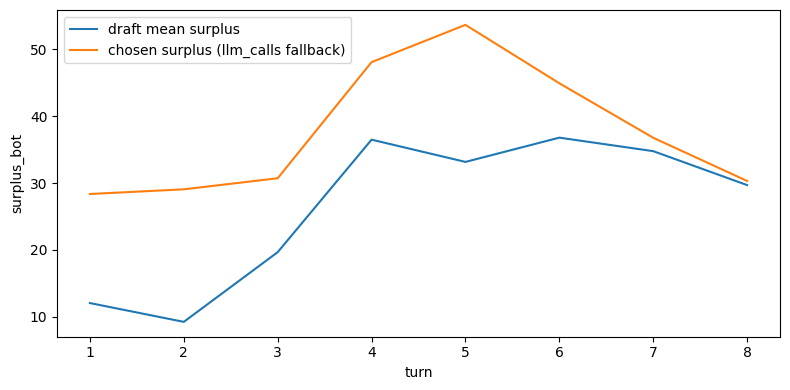

In [107]:
trip = agentic_drafts.groupby('call_id').surplus_bot.agg(['min', 'max', 'mean'])
trip['spread'] = trip['max'] - trip['min']
print('Draft surplus spread within each propose_offer (3 slots)')
print(trip.describe().round(2))

chosen = chosen_effective.copy()
evolution = agentic_drafts.groupby('turn').surplus_bot.mean()
chosen_evolution = chosen.groupby('turn').surplus_bot.mean()

fig, ax = plt.subplots(figsize=(8, 4))
evolution.plot(ax=ax, label='draft mean surplus')
if not chosen_evolution.empty:
    chosen_evolution.plot(ax=ax, label=f'chosen surplus ({chosen_source})')
ax.set_xlabel('turn')
ax.set_ylabel('surplus_bot')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'agentic_surplus_evolution.png', dpi=150)
plt.show()